In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
E192 = [1.00, 1.01, 1.02, 1.04, 1.05, 1.06, 1.07, 1.09, 1.10, 1.11, 1.13, 1.14, 1.15, 1.17, 1.18, 1.20, 1.21, 1.23, 1.24, 1.26, 1.27, 1.29, 1.30, 1.32, 1.33, 1.35, 1.37, 1.38, 1.40, 1.42, 1.43, 1.45, 1.47, 1.49, 1.50, 1.52, 1.54, 1.56, 1.58, 1.60, 1.62, 1.64, 1.65, 1.67, 1.69, 1.72, 1.74, 1.76, 1.78, 1.80, 1.82, 1.84, 1.87, 1.89, 1.91, 1.93, 1.96, 1.98, 2.00, 2.03, 2.05, 2.08, 2.10, 2.13, 2.15, 2.18, 2.21, 2.23, 2.26, 2.29, 2.32, 2.34, 2.37, 2.40, 2.43, 2.46, 2.49, 2.52, 2.55, 2.58, 2.61, 2.64, 2.67, 2.71, 2.74, 2.77, 2.80, 2.84, 2.87, 2.91, 2.94, 2.98, 3.01, 3.05, 3.09, 3.12, 3.16, 3.20, 3.24, 3.28, 3.32, 3.36, 3.40, 3.44, 3.48, 3.52, 3.57, 3.61, 3.65, 3.70, 3.74, 3.79, 3.83, 3.88, 3.92, 3.97, 4.02, 4.07, 4.12, 4.17, 4.22, 4.27, 4.32, 4.37, 4.42, 4.48, 4.53, 4.59, 4.64, 4.70, 4.75, 4.81, 4.87, 4.93, 4.99, 5.05, 5.11, 5.17, 5.23, 5.30, 5.36, 5.42, 5.49, 5.56, 5.62, 5.69, 5.76, 5.83, 5.90, 5.97, 6.04, 6.12, 6.19, 6.26, 6.34, 6.42, 6.49, 6.57, 6.65, 6.73, 6.81, 6.90, 6.98, 7.06, 7.15, 7.23, 7.32, 7.41, 7.50, 7.59, 7.68, 7.77, 7.87, 7.96, 8.06, 8.16, 8.25, 8.35, 8.45, 8.56, 8.66, 8.76, 8.87, 8.98, 9.09, 9.20, 9.31, 9.42, 9.53, 9.65, 9.76, 9.88]

In [19]:
def getVals():
    R_exponent = [1E3, 1E4]
    C_exponent = [1E-6, 1E-9, 1E-12]
    R1 = np.random.choice(E192)*np.random.choice(R_exponent)
    R2 = np.random.choice(E192)*np.random.choice(R_exponent)
    C1 = np.random.choice(E192)*np.random.choice(C_exponent)
    C2 = np.random.choice(E192)*np.random.choice(C_exponent)

    return R1, R2, C1, C2


In [20]:
f = np.logspace(np.log10(10), np.log10(10E9), 9*200)
s = 1j*2*np.pi*f

n = 10000

data = np.empty((n, 2, 9*200+2))

for i in range(n):
    R1, R2, C1, C2 = getVals()
    a = 1/R1 + 1/R2
    hf = (1/R1 * (1 + s*R1*C1)) / (a*(1 + s*C2/a))

    mag = np.abs(hf)
    mag = np.maximum(mag, 1E-10)
    phase = np.unwrap(np.angle(hf))

    data[i, 0, :2] = np.array([R1, R2])
    data[i, 1, :2] = np.array([C1, C2])
    data[i, 0, 2:] = mag
    data[i, 1, 2:] = phase

np.save("data.npy", data)

In [21]:
data = np.load("data.npy")
y = data[:,:,:2].reshape(-1,4)

print(y.shape)
print(y[:3])

(10000, 4)
[[4.17e+03 9.20e+04 2.23e-06 1.43e-06]
 [5.90e+04 4.22e+03 5.30e-12 1.06e-06]
 [4.53e+04 8.06e+03 2.77e-06 5.90e-06]]


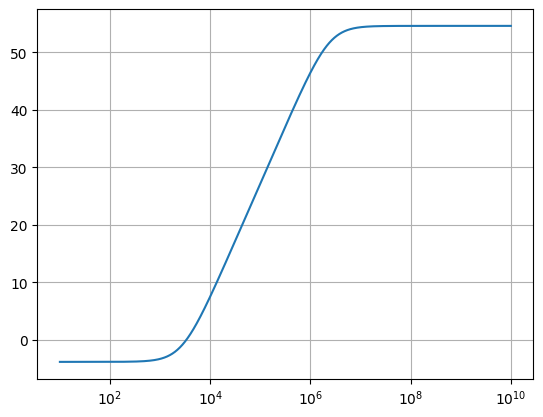

In [22]:
f = np.logspace(np.log10(10), np.log10(10E9), 9*200)
data = np.load("data.npy")

graph = np.random.randint(0,10001)

plt.semilogx(f, 20*np.log10(np.abs(data[graph, 0, 2:])))
plt.grid()
plt.show()

In [23]:
data = np.load('data.npy')

mag = data[:,0,2:]
phase = data[:,1,2:]
print(mag.shape)
print(phase.shape)
X = np.stack([mag,phase], axis=1)
print(X.shape)
y = data[:,:,:2].reshape(-1,4)
print(y.shape)
print(y[0])

(10000, 1800)
(10000, 1800)
(10000, 2, 1800)
(10000, 4)
[4.17e+03 9.20e+04 2.23e-06 1.43e-06]
